____
# Eddy view


In [1]:
import numpy as np
import pandas as pd
import xarray as xr

import matplotlib.pyplot as plt

import os
from glob import glob

from swot import add_mask_inside_swot, build_swath_polygon, plot_swot_tracks
from cstes import (
    swot_dir,
    drifters_dir,
    zarr_dir,
    surface_drifters,
    depth_drifters,
    depth_100,
    depth_50,
    images_dir,
    U2,
    err_acc,
    drifters_structure,
    structure,
)
from diagnosis import (
    update_dict,
    dataset_coloc_combs,
    dataset_coloc_combs,
    prepared_drifters,
    prepared_wd,
    prepared_alti,
    compute_variance_groupby,
    compute_variance,
    put_fig_letter,
)
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import cartopy.geodesic as cgeo

crs = ccrs.PlateCarree()

import cartopy.geodesic as geod
import cartopy.crs as ccrs
import cartopy.feature as cfeature

import pyproj
from pyproj import Geod

from rasterio.transform import Affine

import pynsitu as pyn

from diagnosis import synthetic_figure
from cstes import U2, c0

/Users/mdemol/code/pynsitu/pynsitu/__init__.py:45: FutureWarning: 'H' is deprecated and will be removed in a future version. Please use 'h' instead of 'H'.
  hour = Timedelta("1H")


In [2]:
import cartopy.feature as cfeature
from pyproj import Geod


def scale_bar(ax, length, location=(0.1, 0.23), linewidth=3):
    """
    Ajoute une barre d’échelle en km sur une carte Cartopy.
    - ax : axes matplotlib/cartopy
    - length : longueur de la barre en km
    - location : position (x,y) en coordonnées axes [0,1]
    - linewidth : épaisseur de la barre
    """
    # Projection géodésique pour calculer les distances
    geod = Geod(ellps="WGS84")

    # Récupérer l’étendue actuelle de la carte
    x0, x1, y0, y1 = ax.get_extent(ccrs.PlateCarree())

    # Latitude au centre pour minimiser la distorsion
    lat = (y0 + y1) / 2

    # Point central de la barre
    lon_center = (x0 + x1) / 2
    lat_center = y0 + (y1 - y0) * location[1]

    # Conversion de km → degrés longitude
    lon1 = lon_center - length / (2 * 111) / np.cos(np.deg2rad(lat))
    lon2 = lon_center + length / (2 * 111) / np.cos(np.deg2rad(lat))

    # Tracer la barre
    ax.plot(
        [lon1, lon2],
        [lat_center, lat_center],
        transform=ccrs.PlateCarree(),
        color="k",
        linewidth=linewidth,
        zorder=30,
    )

    # Label
    ax.text(
        lon_center,
        lat_center - (y1 - y0) * 0.02,
        f"{length} km",
        ha="center",
        va="top",
        transform=ccrs.PlateCarree(),
    )

# Characteritics :

In [3]:
def sel_structure(dfr, cmin, lomin, lamin, cmax, lomax, lamax, pass_, drifter_id):
    # id = dfr[(dfr.longitude>=lomin)&(dfr.longitude<=lomax)&(dfr.latitude>=lamin)&(dfr.latitude<=lamax)&(dfr.cycle_number>=cmin)&(dfr.cycle_number<=cmax)].drifter_id.unique()
    id = drifter_id
    dfr = dfr[
        (
            (dfr.drifter_id.isin(id))
            & (dfr.longitude >= lomin)
            & (dfr.longitude <= lomax)
            & (dfr.latitude >= lamin)
            & (dfr.latitude <= lamax)
            & (dfr.cycle_number >= cmin)
            & (dfr.cycle_number <= cmax)
            # &(~((dfr.longitude<4.75)&(dfr.latitude<40.6)))
        )
    ]
    return dfr


def generate_0_15m_coloc_dataframe(freq_band):

    DT = 12

    # SURFACE
    base_dic = dict(
        dt="12h",
        drifter_preprocess="spectral_decomp",
        drifter_preprocess_param=freq_band,
        alti_product_key="swot2km",
        alti_diff_method="fromduacsv",
        alti_diff_method_param="",
        ggd_var="fromduacsv",
        wd_product_key="era5",
        wd_model="rio",
        wd_depth="0",
    )

    comb_list = [base_dic]

    ds0 = dataset_coloc_combs(comb_list, nearest=False, remove_id_outliers=True)
    # ds0 = ds0.where(ds0.depth==0, drop=True)
    # distance_to_coast = ds0.distance_to_coast.isel(id_comb=0)
    # ds0['distance_to_coast'] = ('row_number', distance_to_coast.values)
    # ds0 = ds0.where(ds0.time_to_swot/pd.Timedelta('1h')<DT, drop=True)
    # ds0 = ds0.where((abs(ds0.ggde)<1e-4) & (abs(ds0.ggdn)<1e-4), drop=True)
    # ds0 = ds0.where(ds0.distance_to_coast>distance_to_coast_max, drop=True)

    df0 = ds0.to_dataframe().reset_index().set_index("row_number")

    # DEPTH 15M
    base_dic = dict(
        dt="12h",
        drifter_preprocess="spectral_decomp",
        drifter_preprocess_param=freq_band,
        alti_product_key="swot2km",
        alti_diff_method="fromduacsv",
        alti_diff_method_param="",
        ggd_var="fromduacsv",
        wd_product_key="era5",
        wd_model="rio",
        wd_depth="15",
    )

    comb_list = [
        base_dic,
    ]

    ds15 = dataset_coloc_combs(comb_list, nearest=False, remove_id_outliers=True)
    # ds15 =ds15.where(ds15.depth==15, drop=True)
    # distance_to_coast = ds15.distance_to_coast.isel(id_comb=0)
    # ds15['distance_to_coast'] = ('row_number', distance_to_coast.values)
    ds15 = ds15.where(ds15.time_to_swot / pd.Timedelta("1h") < DT, drop=True)
    # ds15 = ds15.where((abs(ds15.ggde)<1e-4) & (abs(ds15.ggdn)<1e-4), drop=True)
    # ds15 = ds15.where(ds15.distance_to_coast>distance_to_coast_max, drop=True)

    df15 = ds15.to_dataframe().reset_index().set_index("row_number")

    return df0, df15


def inverse_sign_reconstruction(df):
    var = ["acce", "core", "ggde", "wde", "sumn", "accn", "corn", "ggdn", "wdn"]
    for v in var:
        df[v] = -df[v]


df0, df15 = generate_0_15m_coloc_dataframe("LF")
inverse_sign_reconstruction(df0)
inverse_sign_reconstruction(df15)

FileNotFoundError: [Errno 2] No such file or directory: '/home/datawork-lops-oc/aponte/margot/DATA_MED_COLOC_v2.0.1/coloc_files/drifters/drifterscoloc_12h_spectral_decomp_all_med_variational_10min_v1.csv'

In [4]:
df0["sume"] = df0.acce + df0.core + df0.ggde + df0.wde
df0["sumn"] = df0.accn + df0.corn + df0.ggdn + df0.wdn

df15["sume"] = df15.acce + df15.core + df15.ggde + df15.wde
df15["sumn"] = df15.accn + df15.corn + df15.ggdn + df15.wdn

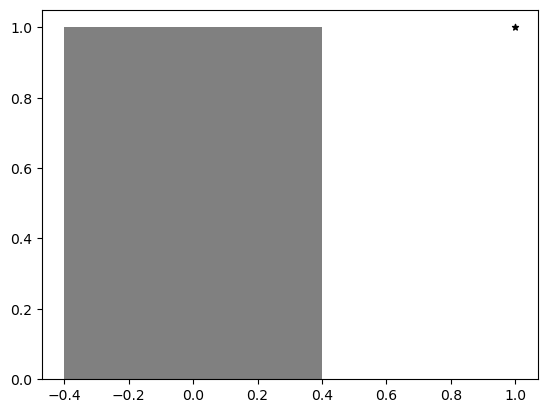

In [5]:
fig, ax = plt.subplots()
ax.scatter(x=[1], y=[1], marker="*", s=20, color="k", label="SWOT matchup")
ax.bar(0, 1, color=c0["acc"], label="Lagrangian acceleration")
ax.bar(0, 1, color=c0["cor"], label="Coriolis acceleration")
ax.bar(0, 1, color=c0["ggd"], label="Pressure gradient term")
ax.bar(0, 1, color=c0["wd"], label="Wind term")
ax.bar(0, 1, color="grey", label="Residual")
# ax.bar(0,1, color='lightgrey', label='Residual contribution')

handles, labels = ax.get_legend_handles_labels()

10
300534060112360


/dev/shm/pbs.3990365.datarmor0/ipykernel_56768/3225956156.py:77: UserWarning: The figure layout has changed to tight
  fig.tight_layout(rect=[0, 0.1, 1, 1])


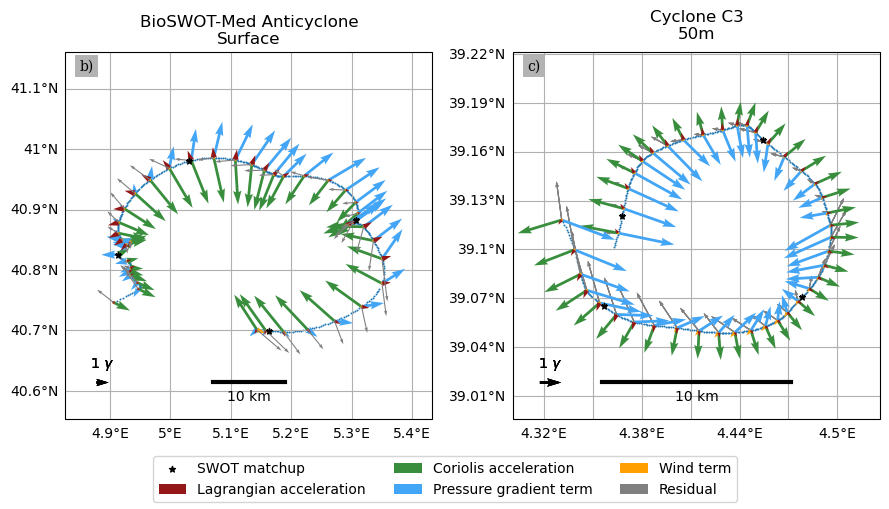

In [9]:
fig, axs = plt.subplots(
    1,
    2,
    figsize=(9, 5),
    frameon=False,
    subplot_kw=dict(projection=ccrs.PlateCarree()),
    layout="constrained",
)

ax = axs[0]

k = "BioSWOT-Med anticyclone A1"
id = "10"
dfa = sel_structure(df0, **structure[k])
dsa = (
    dfa[dfa.drifter_id == id]
    .set_index("cycle_number")
    .to_xarray()
    .set_coords(["longitude", "latitude"])
)

kw = dict(s=2, linewidths=0, transform=crs)
# fig, axs = plt.subplots(5, 1, figsize=(6,6), frameon=False, subplot_kw=dict(projection=ccrs.PlateCarree()), layout='constrained')

dsa_ = dsa.isel(cycle_number=slice(0, -60))

dsa_.plot.scatter(x="longitude", y="latitude", ax=ax, **kw)
dsa_.where(dsa_.time_to_swot < pd.Timedelta("5min"), drop=True).plot.scatter(
    x="longitude", y="latitude", ax=ax, marker="*", s=20, color="k", zorder=15
)
scale = 3e-4
for v in ["cor", "ggd", "wd", "acc"]:
    c = dsa_.isel(cycle_number=slice(0, -1, 12)).plot.quiver(
        x="longitude",
        y="latitude",
        u=v + "e",
        v=v + "n",
        color=c0[v],
        pivot="tail",
        scale=scale,
        zorder=10,
        add_guide=False,
        transform=crs,
        ax=ax,
    )
    ax.quiverkey(
        c,
        0.1,
        0.1,
        np.sqrt(U2),
        r"1 $\gamma$",
        coordinates="axes",
        labelpos="N",
        color="k",
    )
(-dsa_[["longitude", "latitude", "sume", "sumn"]]).isel(
    cycle_number=slice(0, -1, 12)
).plot.quiver(
    x="longitude",
    y="latitude",
    u="sume",
    v="sumn",
    color="grey",
    pivot="tail",
    scale=scale,
    zorder=10,
    add_guide=False,
    transform=crs,
    ax=ax,
    width=3e-3,
)

ax.set_title(f"BioSWOT-Med Anticyclone" + "\n" + "Surface")
print(f"{id}")


# ax.add_feature(cfeature.LAND,)
dl = 0.08
dlat = (dsa_.longitude.max() + 2 * dl - dsa_.longitude.min()) / 2
ax.set_extent(
    [
        dsa_.longitude.min() - dl,
        dsa_.longitude.max() + dl,
        dsa_.latitude.mean() - dlat,
        dsa_.latitude.mean() + dlat,
    ]
)
# ax.set_extent([dfa.longitude.min()-dl,dfa.longitude.max()+dl, dfa.latitude.min()-dl,dfa.latitude.max()+dl] )
gl = ax.gridlines(
    draw_labels=True,
)
gl.top_labels = False
gl.right_labels = False
put_fig_letter(fig, ax, "b")


ax = axs[1]
k = "Cyclone C3"
id = "300534060112360"

dfa = sel_structure(df15, **structure[k])
dsa = (
    dfa[dfa.drifter_id == id]
    .set_index("cycle_number")
    .to_xarray()
    .set_coords(["longitude", "latitude"])
)

kw = dict(s=2, linewidths=0, transform=crs)
# fig, axs = plt.subplots(5, 1, figsize=(6,6), frameon=False, subplot_kw=dict(projection=ccrs.PlateCarree()), layout='constrained')

dsa_ = dsa.isel(cycle_number=slice(20, 520))

dsa_.plot.scatter(x="longitude", y="latitude", ax=ax, **kw)
dsa_.where(dsa_.time_to_swot < pd.Timedelta("5min"), drop=True).plot.scatter(
    x="longitude", y="latitude", ax=ax, marker="*", s=20, color="k", zorder=15
)
scale = 1.7e-4
for v in ["cor", "ggd", "wd", "acc"]:
    c = dsa_.isel(cycle_number=slice(0, -1, 12)).plot.quiver(
        x="longitude",
        y="latitude",
        u=v + "e",
        v=v + "n",
        color=c0[v],
        pivot="tail",
        scale=scale,
        zorder=10,
        add_guide=False,
        transform=crs,
        ax=ax,
    )
    ax.quiverkey(
        c,
        0.1,
        0.1,
        np.sqrt(U2),
        r"1 $\gamma$",
        coordinates="axes",
        labelpos="N",
        color="k",
    )
    (-dsa_[["longitude", "latitude", "sume", "sumn"]]).isel(
        cycle_number=slice(0, -1, 12)
    ).plot.quiver(
        x="longitude",
        y="latitude",
        u="sume",
        v="sumn",
        color="grey",
        pivot="tail",
        scale=scale,
        zorder=5,
        add_guide=False,
        transform=crs,
        ax=ax,
        width=3e-3,
    )
# ax.set_title(f'{dfa.drifter_id.unique()[i]}')
print(f"{id}")
ax.set_title(f"Cyclone C3" + "\n" + "50m")

# ax.add_feature(cfeature.LAND,)
dl = 0.03
dlat = (dsa_.longitude.max() + 2 * dl - dsa_.longitude.min()) / 2
ax.set_extent(
    [
        dsa_.longitude.min() - dl,
        dsa_.longitude.max() + dl,
        dsa_.latitude.mean() - dlat,
        dsa_.latitude.mean() + dlat,
    ]
)
gl = ax.gridlines(
    draw_labels=True,
)
gl.top_labels = False
gl.right_labels = False
put_fig_letter(fig, ax, "c")


scale_bar(axs[0], 10, location=(0.1, 0.1), linewidth=3)

scale_bar(axs[1], 10, location=(0.1, 0.1), linewidth=3)
fig.legend(handles, labels, ncol=3, loc="lower center")

fig.tight_layout(rect=[0, 0.1, 1, 1])

In [35]:
dsa_.where(dsa_.time_to_swot < pd.Timedelta("2h"), drop=True)

<xarray.Dataset> Size: 32kB
Dimensions:            (cycle_number: 96)
Coordinates:
    longitude          (cycle_number) float64 768B 4.348 4.349 ... 4.365 4.364
    latitude           (cycle_number) float64 768B 39.07 39.07 ... 39.11 39.11
  * cycle_number       (cycle_number) int64 768B 529 529 529 529 ... 532 532 532
Data variables: (12/39)
    id_comb            (cycle_number) object 768B '12h_spectral_decomp_all_me...
    sume               (cycle_number) float64 768B -5.683e-06 ... -5.664e-06
    acce               (cycle_number) float64 768B -1.589e-06 ... -1.513e-06
    exce_acc           (cycle_number) float64 768B -7.272e-06 ... -7.177e-06
    core               (cycle_number) float64 768B -1.362e-05 ... -1.811e-05
    exce_cor           (cycle_number) float64 768B -1.93e-05 ... -2.377e-05
    ...                 ...
    time_to_swot       (cycle_number) timedelta64[ns] 768B 01:54:43.470334400...
    drifter_id         (cycle_number) object 768B '300534060112360' ... '3005...
    drifter_type       (cycle_number) object 768B 'SVP' 'SVP' ... 'SVP' 'SVP'
    depth              (cycle_number) float64 768B 50.0 50.0 50.0 ... 50.0 50.0
    phi                (cycle_number) float64 768B 0.2284 0.2285 ... 0.2287
    distance_to_coast  (cycle_number) float64 768B 8.175e+04 ... 7.776e+04

In [ ]:
def plot_structure(df0, k):
    dfa = sel_structure(df0, **structure[k])
    nid = len(dfa.drifter_id.unique())
    row, col = nid // 3, 3
    if row * col < nid:
        row += 1
    print(row, col)
    fig, axs = plt.subplots(
        row,
        col,
        figsize=(15, 4 * row),
        frameon=False,
        subplot_kw=dict(projection=ccrs.PlateCarree()),
        layout="constrained",
    )
    axs = axs.flatten()

    for i in range(len(dfa.drifter_id.unique())):
        ax = axs[i]
        dsa = (
            dfa[dfa.drifter_id == dfa.drifter_id.unique()[i]]
            .set_index("cycle_number")
            .to_xarray()
            .set_coords(["longitude", "latitude"])
        )

        kw = dict(s=2, linewidths=0, transform=crs)
        # fig, axs = plt.subplots(5, 1, figsize=(6,6), frameon=False, subplot_kw=dict(projection=ccrs.PlateCarree()), layout='constrained')

        dsa.plot.scatter(x="longitude", y="latitude", ax=ax, **kw)
        scale = 3e-4
        for v in ["cor", "ggd", "wd", "acc"]:
            c = dsa.isel(cycle_number=slice(0, -1, 10)).plot.quiver(
                x="longitude",
                y="latitude",
                u=v + "e",
                v=v + "n",
                color=c0[v],
                pivot="tail",
                scale=scale,
                zorder=10,
                add_guide=False,
                transform=crs,
                ax=ax,
            )
            ax.quiverkey(
                c,
                0.95,
                0.03,
                np.sqrt(U2),
                r"1 $\gamma$",
                coordinates="figure",
                labelpos="N",
                color="k",
            )
        ax.set_title(f"{dfa.drifter_id.unique()[i]}")
        print(f"{dfa.drifter_id.unique()[i]}")

        # ax.add_feature(cfeature.LAND,)
        dl = 0.1
        ax.set_extent(
            [
                dfa.longitude.min() - dl,
                dfa.longitude.max() + dl,
                dfa.latitude.min() - dl,
                dfa.latitude.max() + dl,
            ]
        )
        gl = ax.gridlines(
            draw_labels=True,
        )
        gl.top_labels = False
        gl.right_labels = False

In [240]:
structure.keys()

dict_keys(['Dipole D1', 'Cyclone C2', 'Cyclone C3', 'Anticyclone A3', 'Cyclone C1', 'BioSWOT-Med', 'BioSWOT-Med front F1', 'BioSWOT-Med anticyclone A1', 'FaSt-SWOT anticyclone A2'])

11 3
4694122
4694103
6204605
4694040
279
6204607
280
278
6204608
6204606
6204604
286
284
4694198
281
287
288
283
4694188
285
4694203
4694193
4694201
4694199
4694189
289
282
4694206
4694461
4694223
4694458


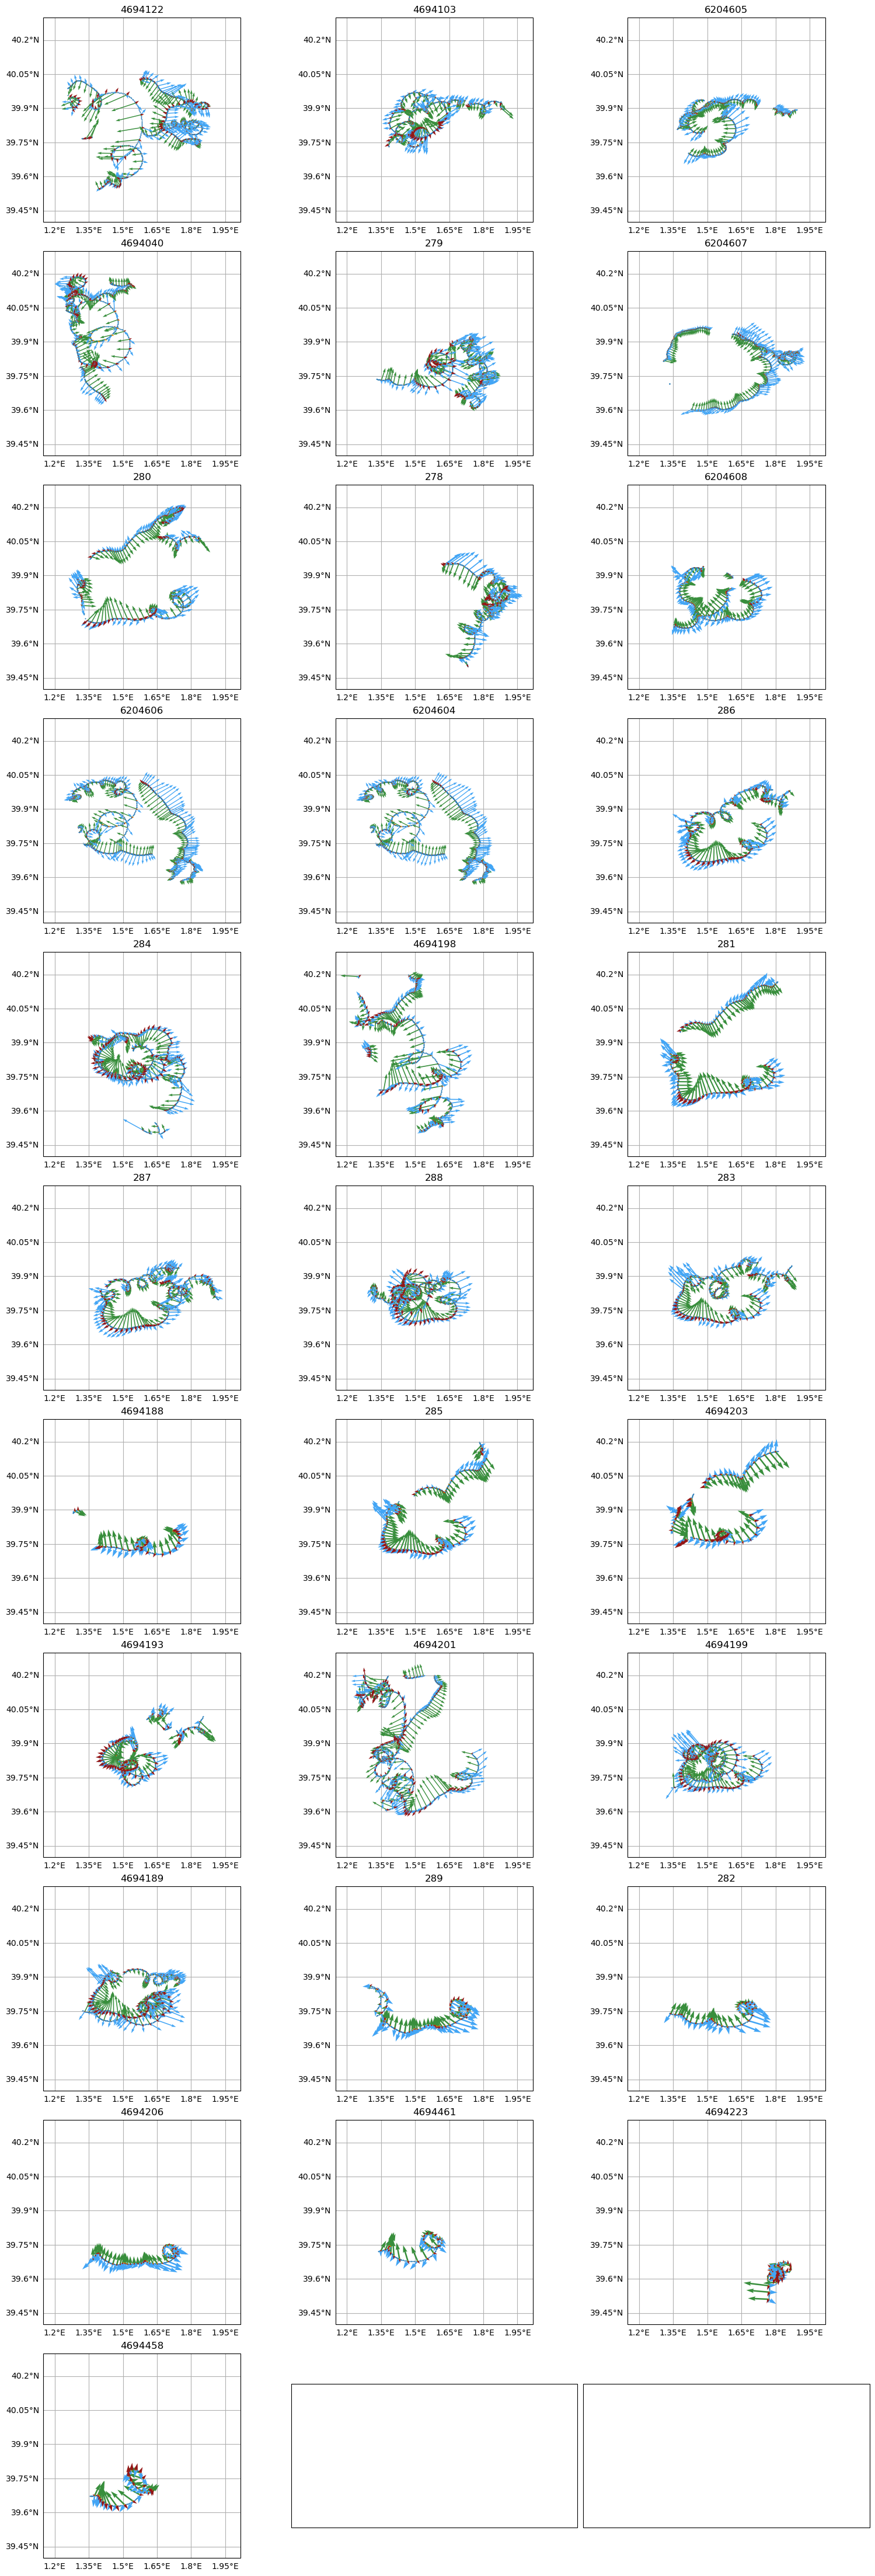

In [241]:
plot_structure(df15, "FaSt-SWOT anticyclone A2")

3 3
300534060017440
300534062479690
300534061170360
300534060015760
4388589
0-4388635
13


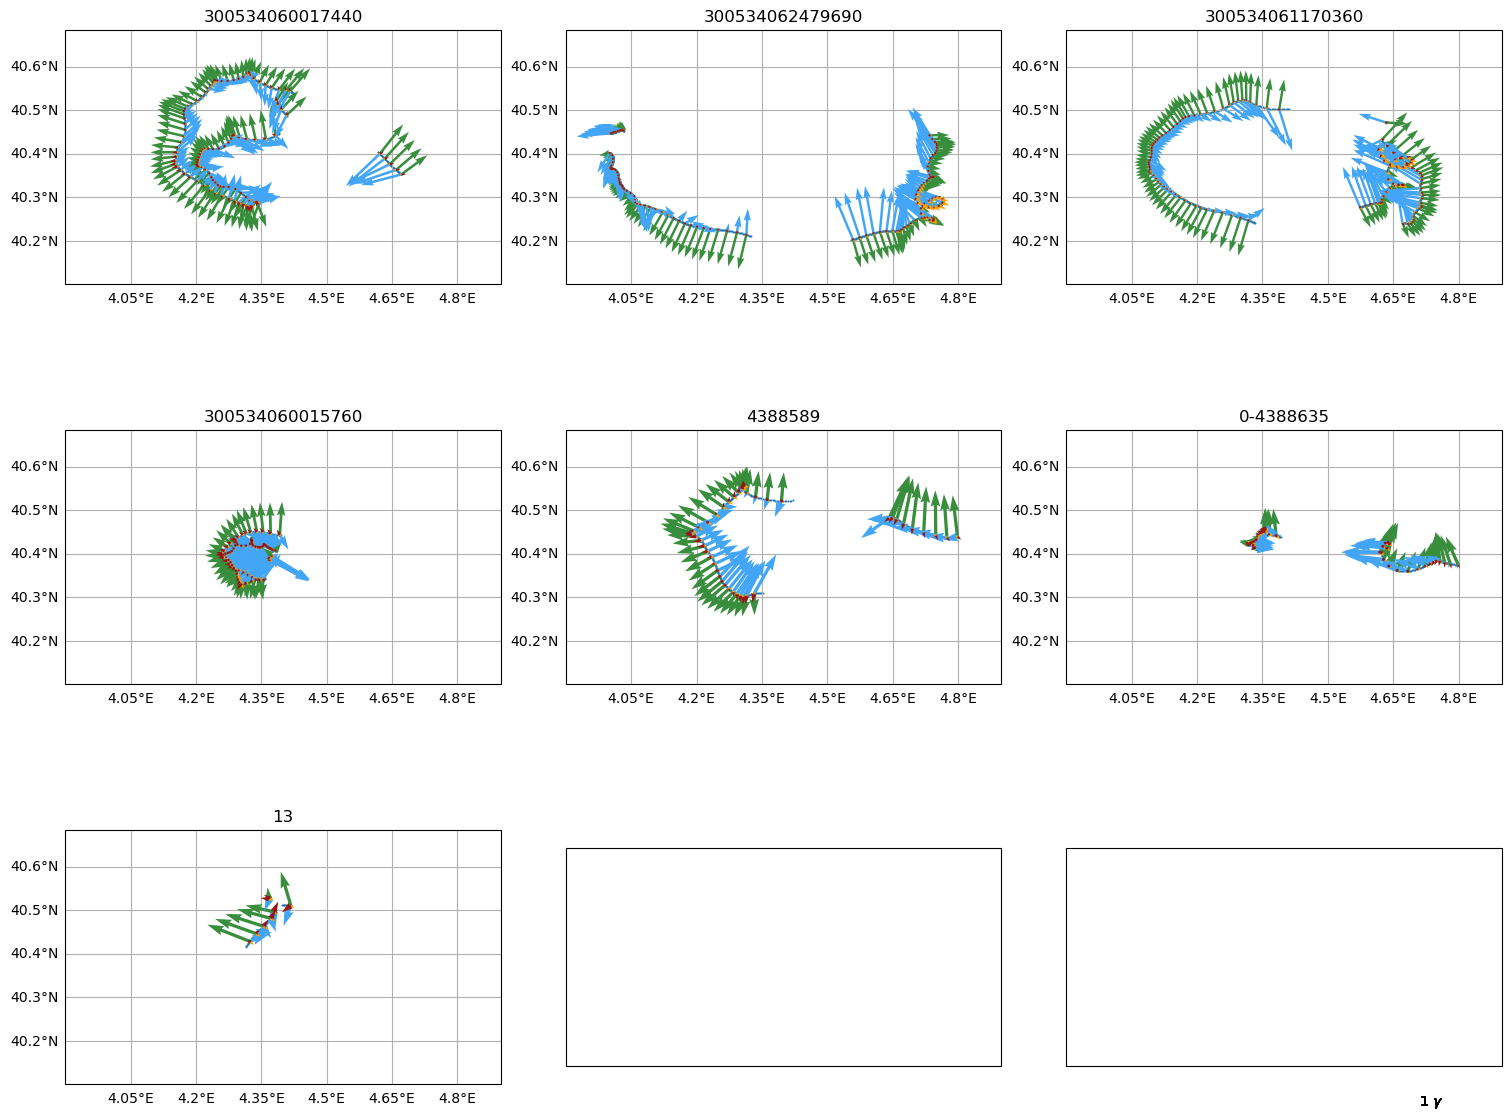

In [242]:
plot_structure(df15, "Cyclone C1")

1 3
300534060116350
300534060315840
300534062470440


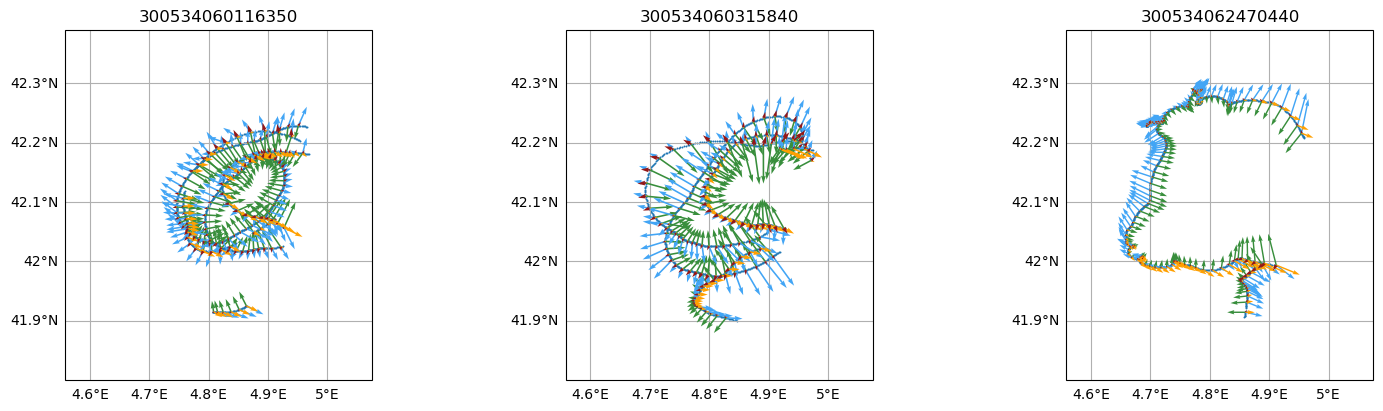

In [243]:
# plot_structure(df0, 'Anticyclone A3')
plot_structure(df15, "Anticyclone A3")

11 3
300534062472690
300534060218400
300534062471390
4388589
4388625
300534064109870
300534060216070
6
4388587
300534064109890
4388636
4388559
9
10
4389458
300534064300460
4389089
300534061395970
4388942
300534064300510
4388943
147
4389467
4388938
300534061395980
300534061398910
4388923
300534061395960
300534061398320
4389009
4388926
300534061398370
300534061492130


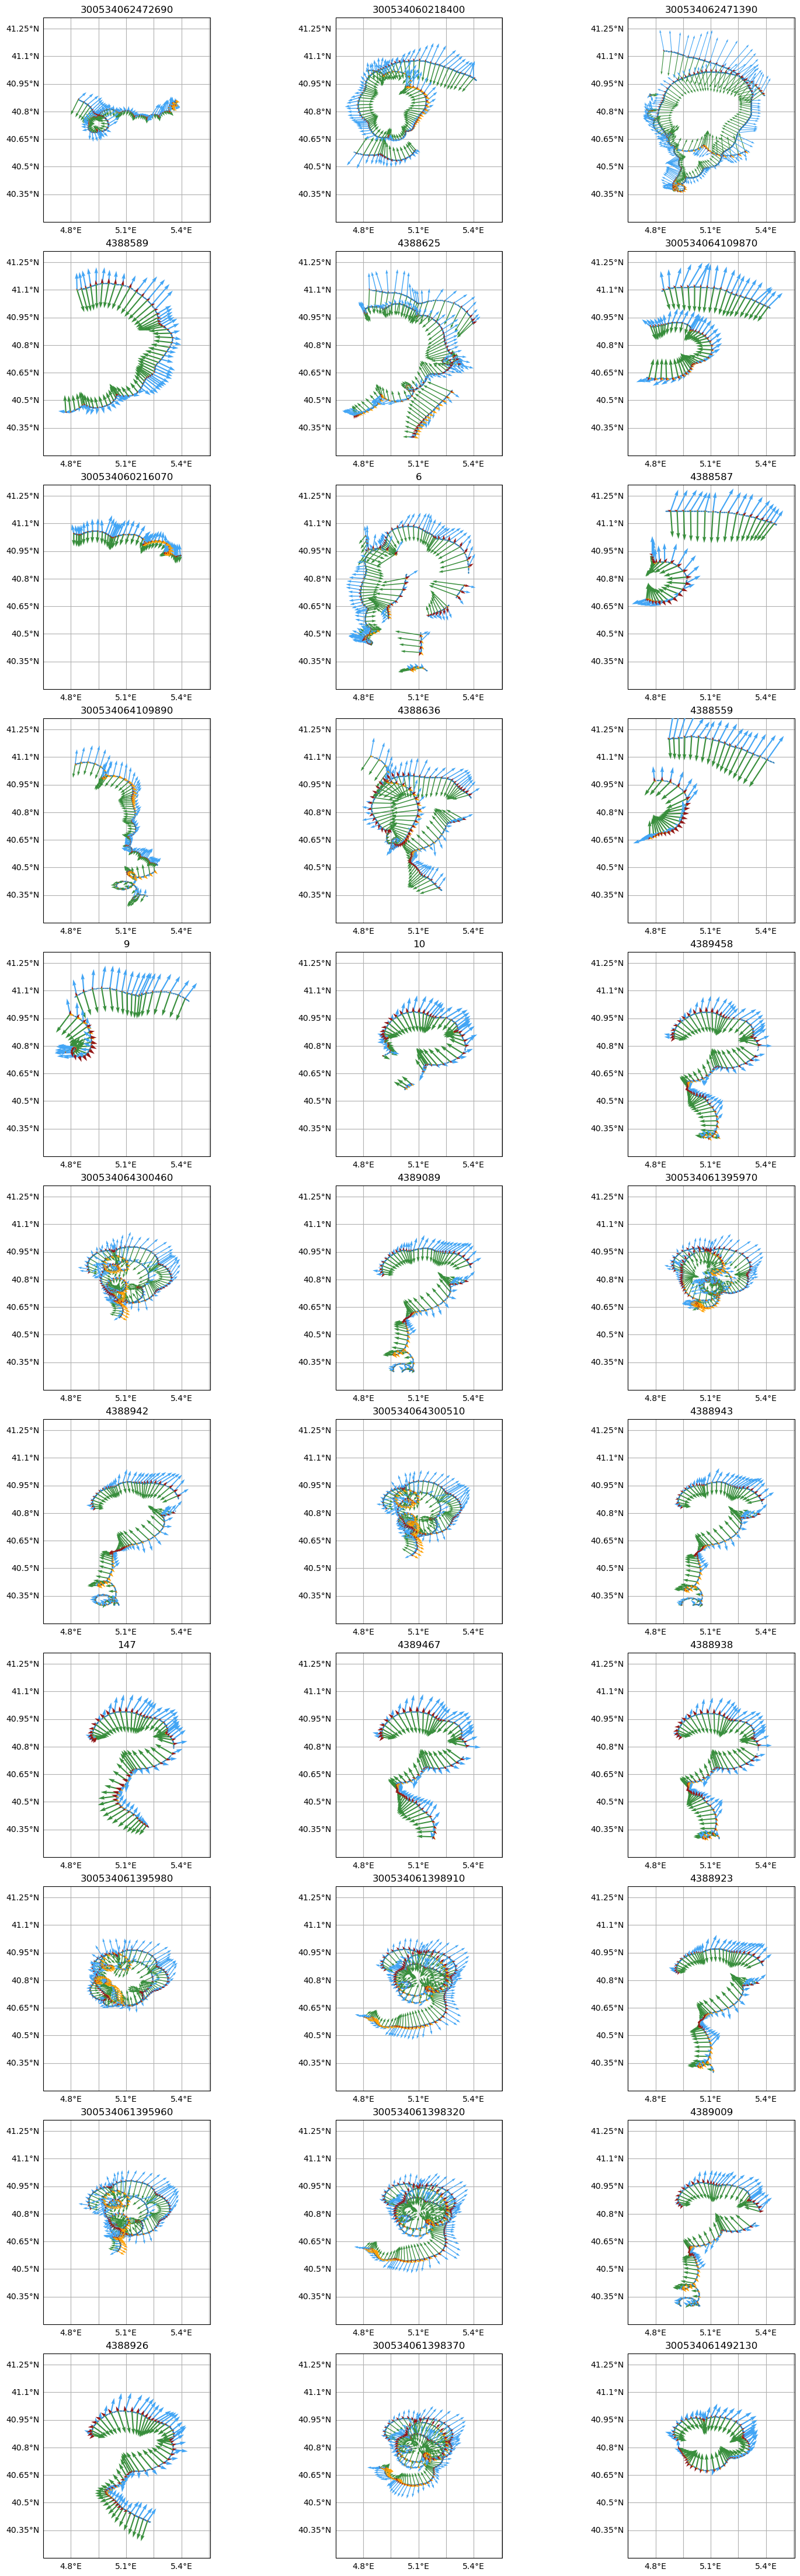

In [244]:
plot_structure(df15, "BioSWOT-Med anticyclone A1")

11 3
300534062472690
300534060218400
300534062471390
4388589
4388625
300534064109870
300534060216070
6
4388587
300534064109890
4388636
4388559
9
10
4389458
300534064300460
4389089
300534061395970
4388942
300534064300510
4388943
147
4389467
4388938
300534061395980
300534061398910
4388923
300534061395960
300534061398320
4389009
4388926
300534061398370
300534061492130


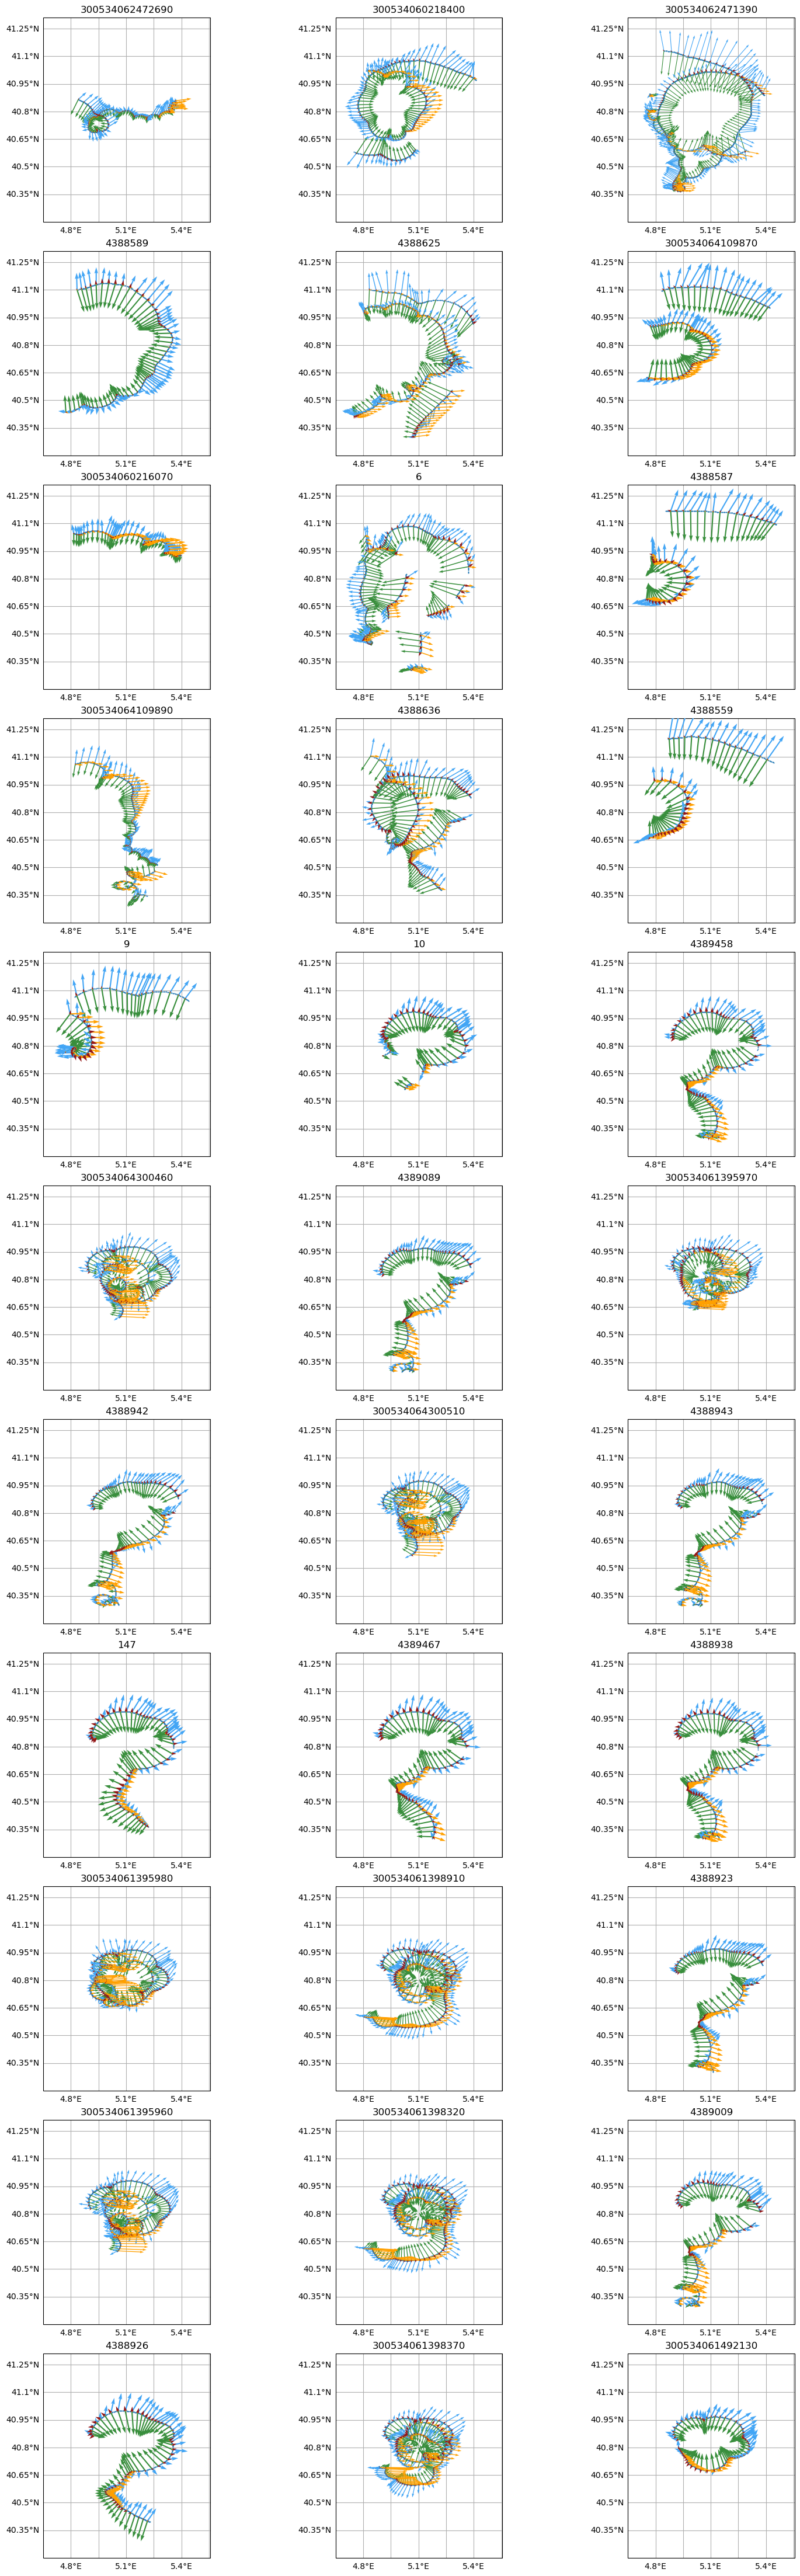

In [253]:
plot_structure(df0, "BioSWOT-Med anticyclone A1")

1 3
300534060112360


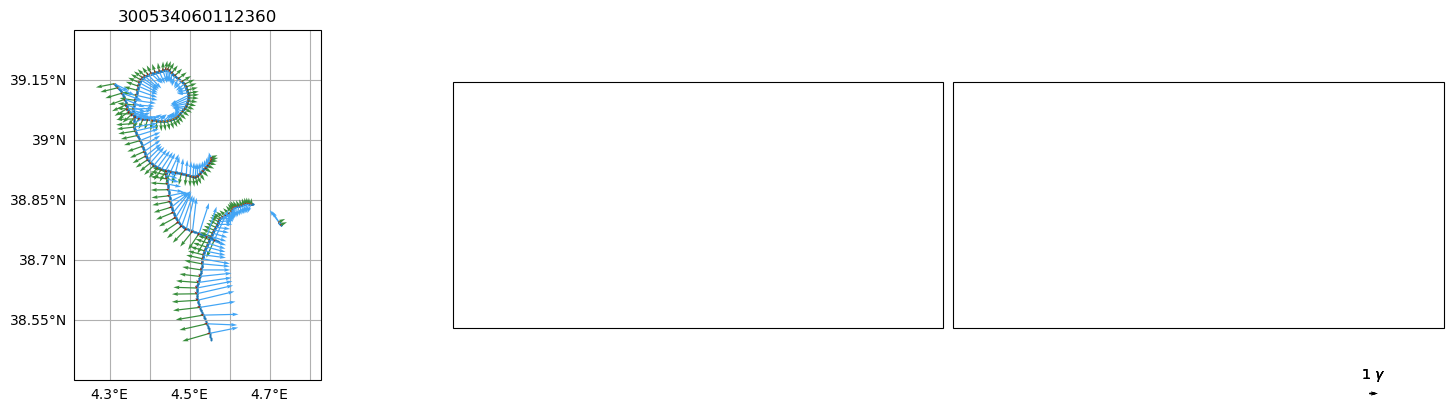

In [254]:
plot_structure(df15, "Cyclone C3")

300534062472690


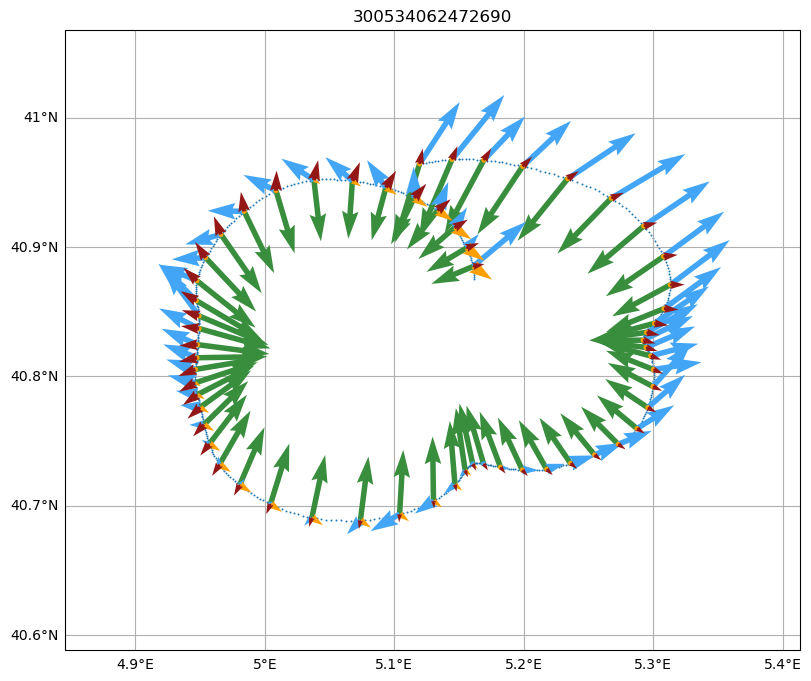

In [255]:
k = "BioSWOT-Med anticyclone A1"
id = "300534061395970"

dfa = sel_structure(df15, **structure[k])
fig, ax = plt.subplots(
    1,
    1,
    figsize=(8, 8),
    frameon=False,
    subplot_kw=dict(projection=ccrs.PlateCarree()),
    layout="constrained",
)
dsa = (
    dfa[dfa.drifter_id == id]
    .set_index("cycle_number")
    .to_xarray()
    .set_coords(["longitude", "latitude"])
)

kw = dict(s=2, linewidths=0, transform=crs)
# fig, axs = plt.subplots(5, 1, figsize=(6,6), frameon=False, subplot_kw=dict(projection=ccrs.PlateCarree()), layout='constrained')

dsa_ = dsa.isel(cycle_number=slice(150, -1000))

dsa_.plot.scatter(x="longitude", y="latitude", ax=ax, **kw)
scale = 3e-4
for v in ["cor", "ggd", "wd", "acc"]:
    c = dsa_.isel(cycle_number=slice(0, -1, 10)).plot.quiver(
        x="longitude",
        y="latitude",
        u=v + "e",
        v=v + "n",
        color=c0[v],
        pivot="tail",
        scale=scale,
        zorder=10,
        add_guide=False,
        transform=crs,
        ax=ax,
    )
    ax.quiverkey(
        c,
        0.95,
        0.03,
        np.sqrt(U2),
        r"1 $\gamma$",
        coordinates="figure",
        labelpos="N",
        color="k",
    )
ax.set_title(f"{dfa.drifter_id.unique()[i]}")
print(f"{dfa.drifter_id.unique()[i]}")


# ax.add_feature(cfeature.LAND,)
dl = 0.1
ax.set_extent(
    [
        dsa_.longitude.min() - dl,
        dsa_.longitude.max() + dl,
        dsa_.latitude.min() - dl,
        dsa_.latitude.max() + dl,
    ]
)
# ax.set_extent([dfa.longitude.min()-dl,dfa.longitude.max()+dl, dfa.latitude.min()-dl,dfa.latitude.max()+dl] )
gl = ax.gridlines(
    draw_labels=True,
)
gl.top_labels = False
gl.right_labels = False

300534062472690


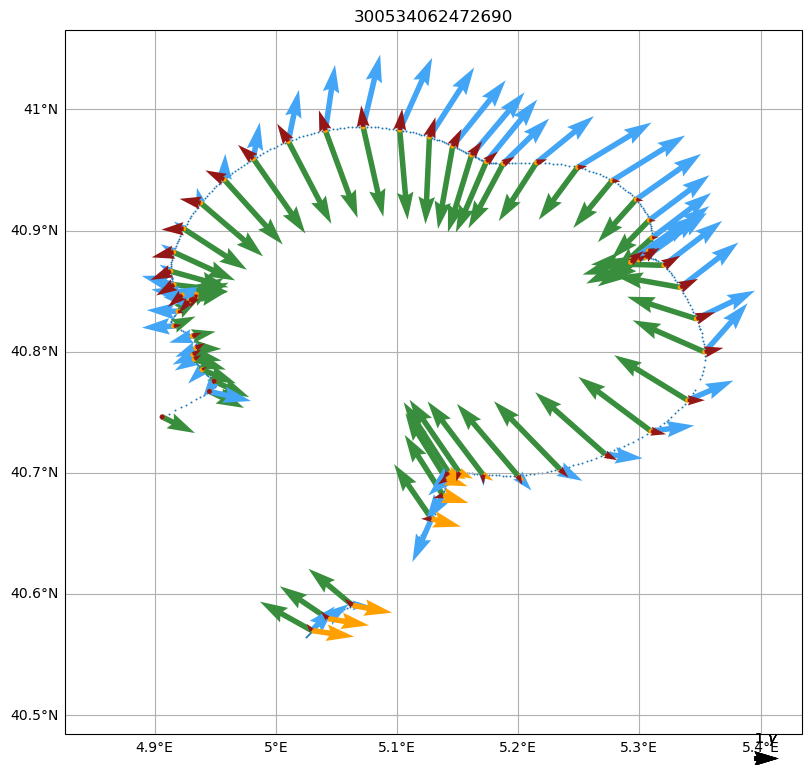

In [256]:
k = "BioSWOT-Med anticyclone A1"
id = "10"

dfa = sel_structure(df0, **structure[k])
fig, ax = plt.subplots(
    1,
    1,
    figsize=(8, 8),
    frameon=False,
    subplot_kw=dict(projection=ccrs.PlateCarree()),
    layout="constrained",
)
dsa = (
    dfa[dfa.drifter_id == id]
    .set_index("cycle_number")
    .to_xarray()
    .set_coords(["longitude", "latitude"])
)

kw = dict(s=2, linewidths=0, transform=crs)
# fig, axs = plt.subplots(5, 1, figsize=(6,6), frameon=False, subplot_kw=dict(projection=ccrs.PlateCarree()), layout='constrained')

dsa_ = dsa  # .isel(cycle_number=slice(150, -1000))

dsa_.plot.scatter(x="longitude", y="latitude", ax=ax, **kw)
scale = 3e-4
for v in ["cor", "ggd", "wd", "acc"]:
    c = dsa_.isel(cycle_number=slice(0, -1, 10)).plot.quiver(
        x="longitude",
        y="latitude",
        u=v + "e",
        v=v + "n",
        color=c0[v],
        pivot="tail",
        scale=scale,
        zorder=10,
        add_guide=False,
        transform=crs,
        ax=ax,
    )
    ax.quiverkey(
        c,
        0.95,
        0.03,
        np.sqrt(U2),
        r"1 $\gamma$",
        coordinates="figure",
        labelpos="N",
        color="k",
    )
ax.set_title(f"{dfa.drifter_id.unique()[i]}")
print(f"{dfa.drifter_id.unique()[i]}")


# ax.add_feature(cfeature.LAND,)
dl = 0.08
ax.set_extent(
    [
        dsa_.longitude.min() - dl,
        dsa_.longitude.max() + dl,
        dsa_.latitude.min() - dl,
        dsa_.latitude.max() + dl,
    ]
)
# ax.set_extent([dfa.longitude.min()-dl,dfa.longitude.max()+dl, dfa.latitude.min()-dl,dfa.latitude.max()+dl] )
gl = ax.gridlines(
    draw_labels=True,
)
gl.top_labels = False
gl.right_labels = False

300534060112360


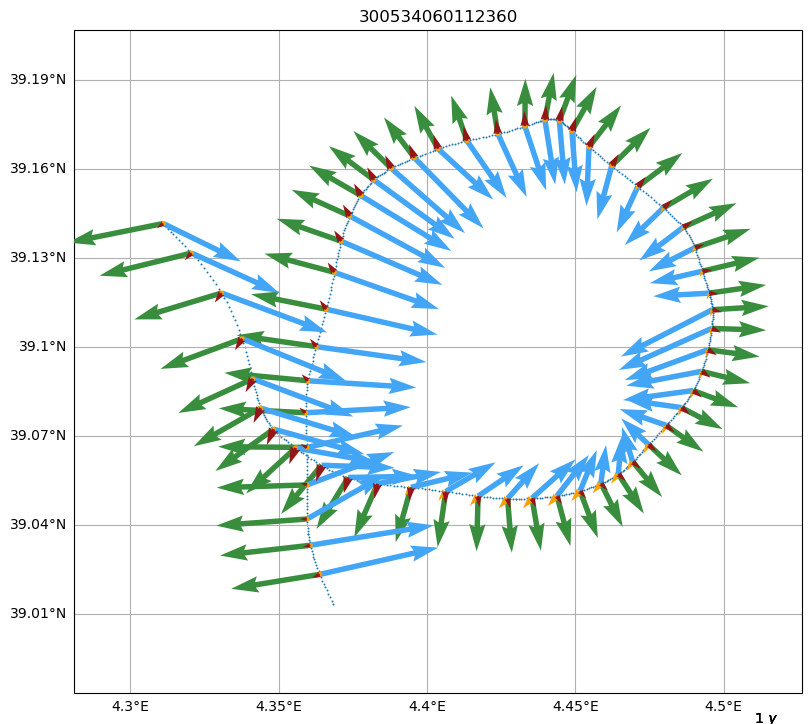

In [257]:
k = "Cyclone C3"
id = "300534060112360"

dfa = sel_structure(df15, **structure[k])
fig, ax = plt.subplots(
    1,
    1,
    figsize=(8, 8),
    frameon=False,
    subplot_kw=dict(projection=ccrs.PlateCarree()),
    layout="constrained",
)
dsa = (
    dfa[dfa.drifter_id == id]
    .set_index("cycle_number")
    .to_xarray()
    .set_coords(["longitude", "latitude"])
)

kw = dict(s=2, linewidths=0, transform=crs)
# fig, axs = plt.subplots(5, 1, figsize=(6,6), frameon=False, subplot_kw=dict(projection=ccrs.PlateCarree()), layout='constrained')

dsa_ = dsa.isel(cycle_number=slice(0, 600))

dsa_.plot.scatter(x="longitude", y="latitude", ax=ax, **kw)
scale = 1.7e-4
for v in ["cor", "ggd", "wd", "acc"]:
    c = dsa_.isel(cycle_number=slice(0, -1, 10)).plot.quiver(
        x="longitude",
        y="latitude",
        u=v + "e",
        v=v + "n",
        color=c0[v],
        pivot="tail",
        scale=scale,
        zorder=10,
        add_guide=False,
        transform=crs,
        ax=ax,
    )
    ax.quiverkey(
        c,
        0.95,
        0.03,
        np.sqrt(U2),
        r"1 $\gamma$",
        coordinates="figure",
        labelpos="N",
        color="k",
    )
ax.set_title(f"{dfa.drifter_id.unique()[i]}")
print(f"{dfa.drifter_id.unique()[i]}")


# ax.add_feature(cfeature.LAND,)
dl = 0.03
ax.set_extent(
    [
        dsa_.longitude.min() - dl,
        dsa_.longitude.max() + dl,
        dsa_.latitude.min() - dl,
        dsa_.latitude.max() + dl,
    ]
)
gl = ax.gridlines(
    draw_labels=True,
)
gl.top_labels = False
gl.right_labels = False

4694122


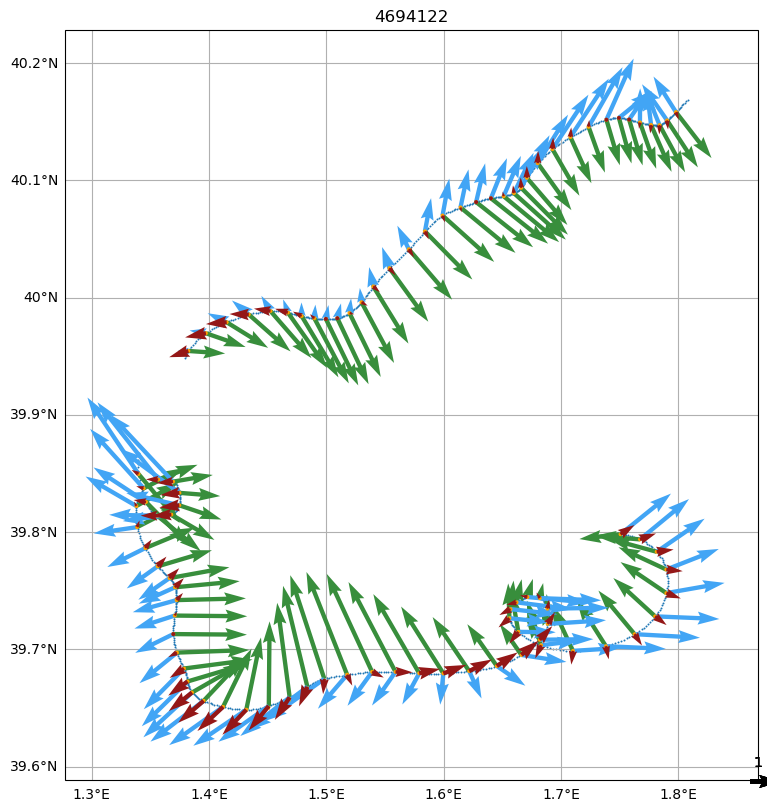

In [250]:
k = "FaSt-SWOT anticyclone A2"
id = "281"

dfa = sel_structure(df15, **structure[k])
fig, ax = plt.subplots(
    1,
    1,
    figsize=(8, 8),
    frameon=False,
    subplot_kw=dict(projection=ccrs.PlateCarree()),
    layout="constrained",
)
dsa = (
    dfa[dfa.drifter_id == id]
    .set_index("cycle_number")
    .to_xarray()
    .set_coords(["longitude", "latitude"])
)

kw = dict(s=2, linewidths=0, transform=crs)
# fig, axs = plt.subplots(5, 1, figsize=(6,6), frameon=False, subplot_kw=dict(projection=ccrs.PlateCarree()), layout='constrained')

dsa_ = dsa  # .isel(cycle_number=slice(0, 600))

dsa_.plot.scatter(x="longitude", y="latitude", ax=ax, **kw)
scale = 2.2e-4
for v in ["cor", "ggd", "wd", "acc"]:
    c = dsa_.isel(cycle_number=slice(0, -1, 10)).plot.quiver(
        x="longitude",
        y="latitude",
        u=v + "e",
        v=v + "n",
        color=c0[v],
        pivot="tail",
        scale=scale,
        zorder=10,
        add_guide=False,
        transform=crs,
        ax=ax,
    )
    ax.quiverkey(
        c,
        0.95,
        0.03,
        np.sqrt(U2),
        r"1 $\gamma$",
        coordinates="figure",
        labelpos="N",
        color="k",
    )
ax.set_title(f"{dfa.drifter_id.unique()[i]}")
print(f"{dfa.drifter_id.unique()[i]}")


# ax.add_feature(cfeature.LAND,)
dl = 0.06
ax.set_extent(
    [
        dsa_.longitude.min() - dl,
        dsa_.longitude.max() + dl,
        dsa_.latitude.min() - dl,
        dsa_.latitude.max() + dl,
    ]
)
gl = ax.gridlines(
    draw_labels=True,
)
gl.top_labels = False
gl.right_labels = False

4694122


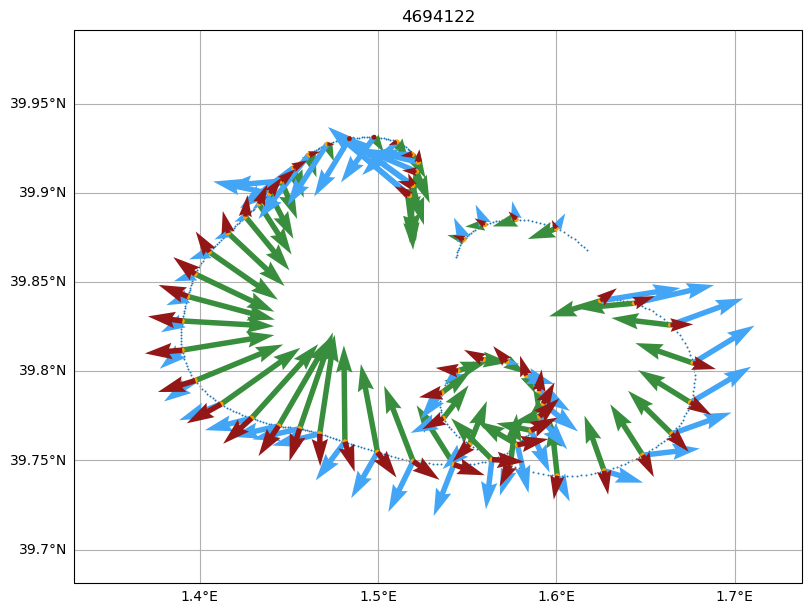

In [251]:
k = "FaSt-SWOT anticyclone A2"
id = "284"

dfa = sel_structure(df15, **structure[k])
fig, ax = plt.subplots(
    1,
    1,
    figsize=(8, 8),
    frameon=False,
    subplot_kw=dict(projection=ccrs.PlateCarree()),
    layout="constrained",
)
dsa = (
    dfa[dfa.drifter_id == id]
    .set_index("cycle_number")
    .to_xarray()
    .set_coords(["longitude", "latitude"])
)

kw = dict(s=2, linewidths=0, transform=crs)
# fig, axs = plt.subplots(5, 1, figsize=(6,6), frameon=False, subplot_kw=dict(projection=ccrs.PlateCarree()), layout='constrained')

dsa_ = dsa.isel(cycle_number=slice(0, 600))

dsa_.plot.scatter(x="longitude", y="latitude", ax=ax, **kw)
scale = 2.2e-4
for v in ["cor", "ggd", "wd", "acc"]:
    c = dsa_.isel(cycle_number=slice(0, -1, 10)).plot.quiver(
        x="longitude",
        y="latitude",
        u=v + "e",
        v=v + "n",
        color=c0[v],
        pivot="tail",
        scale=scale,
        zorder=10,
        add_guide=False,
        transform=crs,
        ax=ax,
    )
    ax.quiverkey(
        c,
        0.95,
        0.03,
        np.sqrt(U2),
        r"1 $\gamma$",
        coordinates="figure",
        labelpos="N",
        color="k",
    )
ax.set_title(f"{dfa.drifter_id.unique()[i]}")
print(f"{dfa.drifter_id.unique()[i]}")


# ax.add_feature(cfeature.LAND,)
dl = 0.06
ax.set_extent(
    [
        dsa_.longitude.min() - dl,
        dsa_.longitude.max() + dl,
        dsa_.latitude.min() - dl,
        dsa_.latitude.max() + dl,
    ]
)
gl = ax.gridlines(
    draw_labels=True,
)
gl.top_labels = False
gl.right_labels = False

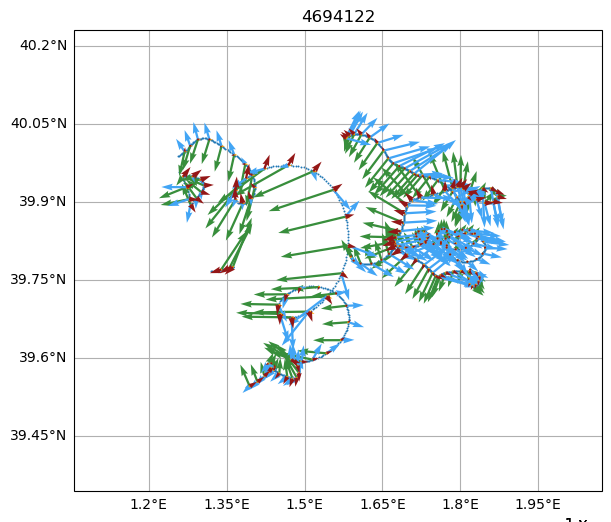

In [252]:
i = 0
dsa = (
    dfa[dfa.drifter_id == dfa.drifter_id.unique()[i]]
    .set_index("cycle_number")
    .to_xarray()
    .set_coords(["longitude", "latitude"])
)

kw = dict(s=2, linewidths=0, transform=crs)
fig, ax = plt.subplots(
    1,
    1,
    figsize=(6, 6),
    frameon=False,
    subplot_kw=dict(projection=ccrs.PlateCarree()),
    layout="constrained",
)


dsa.plot.scatter(x="longitude", y="latitude", ax=ax, **kw)
scale = 3e-4
for v in ["cor", "ggd", "wd", "acc"]:
    c = dsa.isel(cycle_number=slice(0, -1, 10)).plot.quiver(
        x="longitude",
        y="latitude",
        u=v + "e",
        v=v + "n",
        color=c0[v],
        pivot="tail",
        scale=scale,
        zorder=10,
        add_guide=False,
        transform=crs,
    )
    ax.quiverkey(
        c,
        0.95,
        0.03,
        np.sqrt(U2),
        r"1 $\gamma$",
        coordinates="figure",
        labelpos="N",
        color="k",
    )
ax.set_title(f"{dfa.drifter_id.unique()[i]}")


# ax.add_feature(cfeature.LAND,)
dl = 0.2
ax.set_extent(
    [
        dsa.longitude.min() - dl,
        dsa.longitude.max() + dl,
        dsa.latitude.min() - dl,
        dsa.latitude.max() + dl,
    ]
)
gl = ax.gridlines(
    draw_labels=True,
)
gl.top_labels = False
gl.right_labels = False